## BART-BMM Examples

This notebook reproduces the BART-BMM examples shown in "Model Mixing Using Bayesian Additive Regression Trees." Each code cell can be executed by clicking the "play" button, which is found on the lefthand side of the cell. Alternatively, one can click inside the cell and use the command `shift + enter`.

### **Installation Step**

This notebook uses the openbt Python package from this repository (openbt_pypkg), which wraps the OpenBT C++ command line tools.

See the "Getting Started with Python" section of the [OpenBT User Guide](https://openbt.readthedocs.io) for full dependency and installation details.


### **Python Setup**
Next, import the required python libraries.

In [20]:
# Required Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm
from scipy.special import gamma
import sys
import os

The BART-BMM mixing model is provided directly by the `openbt` package's `Openbtmix` class (`openbt.openbtmixing`), which wraps the `openbtcli`, `openbtpred`, and `openbtmixingwts` command line tools built during installation.

Next, we load the data required to reproduce these examples. The training/test data live in the `Data/` folder next to this notebook, and the Honda EFT model definitions live in `eft_models.py` in this same folder.

### **EFT Setup**

The following lines of code import the `sin_cos_exp` Taylor-series model class bundled with `openbt` (used in Example 2) and the Honda EFT model functions from `eft_models.py` (used in Examples 1a/1b). Additionally, the EFT model wrapper class is created (`honda_models`).

In [21]:
# openbt imports
from openbt import Openbtmix
from openbt.tests.polynomial_models import sin_exp, cos_exp, sin_cos_exp


In [22]:
import eft_models as eft

In [23]:
# Wrap honda models
class honda_models:
  def __init__(self,sg = True, N = 2):
        self.N = N
        self.sg = sg

  def evaluate(self, x):
      if isinstance(x, list):
          x = np.array(x)
      if self.sg:
        m = eft.fsg(x,self.N)
        s = eft.dsg(x,self.N)
      else:
        m = eft.flg(x,self.N)
        s = eft.dlg(x,self.N)
      if len(m.shape) == 1:
        m = m.reshape(m.shape[0],1)
        s = s.reshape(s.shape[0],1)
      return m,s


### **Example 1a:**

This section provides the code to reproduce the BART-BMM results for the first EFT example in the manuscript.

The BART-BMM model is trained using the following steps.

1. Define the model set using the two lines of code shown below, each of which creates a class instance for one of the EFT models.

In [24]:
# Load the models
fs2 = honda_models(True,2)
fl4 = honda_models(False,4)


In [25]:
# Format training and test data
x_train = np.linspace(0.03,0.5,num = 20)
x_test = np.linspace(0.03,0.5,num = 200)
y_train = np.loadtxt("Data/honda_y_train.txt")

y_train = y_train.reshape(20,1)
x_train = x_train.reshape(20,1)
x_test = x_test.reshape(200,1)


2. Define the class instance of the BART-BMM model using the `Openbtmix` class. For this example, the class instance is called `mix`.

3. Set the prior information using the `set_prior()` method.

4. Fit the model using `train()`. This requires the user to pass in the data, the evaluated model set (`f_train`), the informative-prior standard deviations (`s_train`), and relevant MCMC arguments.

In [26]:
# Fit the BMM Model
# Evaluate the model set at the training inputs
f_train = np.concatenate([fs2.evaluate(x_train)[0], fl4.evaluate(x_train)[0]], axis=1)
s_train = np.concatenate([fs2.evaluate(x_train)[1], fl4.evaluate(x_train)[1]], axis=1)

# Initialize the Openbtmix class instance
mix = Openbtmix()

# Set prior information
mix.set_prior(k=5.5,ntree=10,nu=5,sighat=0.01,inform_prior=True)

# Train the model
fit = mix.train(x_train=x_train, y_train=y_train, f_train=f_train, s_train=s_train,
                ndpost = 20000, nadapt = 5000, nskip = 2000, adaptevery = 500, minnumbot = 3,
                tc = 2,numcut = 300)


('numcut', 300)
Running model...


5. Obtain the predictions from the mixed function and the corresponding weight functions using the methods `predict()` and `predict_weights()`, respectively. `predict()` requires the test inputs, the evaluated model set at those inputs, and a confidence level; `predict_weights()` requires just the test inputs and a confidence level.

In [27]:
# Evaluate the model set at the test inputs
f_test_arr = np.concatenate([fs2.evaluate(x_test)[0], fl4.evaluate(x_test)[0]], axis=1)

# Get predictions
pred = mix.predict(x_test=x_test, f_test=f_test_arr, ci=0.95)
wts = mix.predict_weights(x_test=x_test, ci=0.95)


6. Plot the resulting predictions and weight functions.

In [28]:
# Predictions - Upper and Lower ci bounds
pmean = pred["pred"]["mean"]
plower = pred["pred"]["lb"]
pupper = pred["pred"]["ub"]

# Weight Functions - Upper and Lower ci bounds
wmean = wts["wts"]["mean"]
wlower = wts["wts"]["lb"]
wupper = wts["wts"]["ub"]

# EFT predictions at test points
f_test = [fs2.evaluate(x_test)[0],fl4.evaluate(x_test)[0]]

# Define the underlying true model
fdagger = eft.f_dagger(x_test)


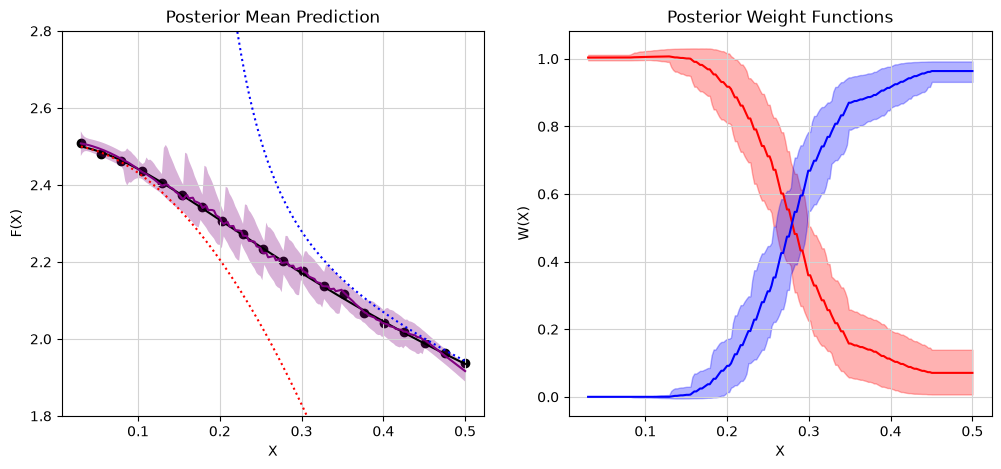

In [29]:
# Plot the predictions and weight functions
col_list = ['red','blue','green','purple','orange']

fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(x_test, fdagger, color = 'black')
ax[0].plot(x_test, pmean, color = 'purple')
for i in range(2):
    ax[0].plot(x_test, f_test[i], color = col_list[i], linestyle = 'dotted')
ax[0].scatter(x_train ,y_train,c="black")
ax[0].set_title("Posterior Mean Prediction")
ax[0].set_xlabel("X")
ax[0].set_ylabel("F(X)")
ax[0].set_ylim(1.8,2.8)
ax[0].fill_between(x_test.reshape(200,), plower, pupper, facecolor='purple', alpha=0.3)
ax[0].grid(True, color='lightgrey')


for i in range(2):
    ax[1].plot(x_test, wmean[:,i], color = col_list[i])
    ax[1].fill_between(x_test.reshape(200,), wlower[:,i], wupper[:,i], color = col_list[i], alpha = 0.3)
ax[1].set_title("Posterior Weight Functions")
ax[1].set_xlabel("X")
ax[1].set_ylabel("W(X)")
ax[1].grid(True, color='lightgrey')


plt.show()

### **Example 1b:**

This section provides the code to reproduce the BART-BMM results for example 1b in the manuscript.

The BART-BMM model is trained using the following steps.

1. Define the model set using the line of code shown below, which creates a class instance for the new EFT model. The other EFT model, `fl4`, is reused from Example 1a.

In [30]:
# Redefine the model set
fs4 = honda_models(True,4)


2. Define the class instance of the BART-BMM model using the `Openbtmix` class. For this example, the class instance is called `mix`.

3. Set the prior information using the `set_prior()` method.

4. Fit the model using `train()`. This requires the user to pass in the data, the evaluated model set (`f_train`), the informative-prior standard deviations (`s_train`), and relevant MCMC arguments.

In [31]:
# Fit the BMM Model
# Evaluate the model set at the training inputs
f_train = np.concatenate([fs4.evaluate(x_train)[0], fl4.evaluate(x_train)[0]], axis=1)
s_train = np.concatenate([fs4.evaluate(x_train)[1], fl4.evaluate(x_train)[1]], axis=1)

# Initialize the Openbtmix class instance
mix = Openbtmix()

# Set prior information
mix.set_prior(k=5.0,ntree=10,nu=5,sighat=0.01,inform_prior=True)

# Train the model
fit = mix.train(x_train=x_train, y_train=y_train, f_train=f_train, s_train=s_train,
                ndpost = 20000, nadapt = 5000, nskip = 2000, adaptevery = 500, minnumbot = 3,
                tc = 2,numcut = 300)


('numcut', 300)
Running model...


5. Obtain the predictions from the mixed function and the corresponding weight functions using the methods `predict()` and `predict_weights()`, respectively. `predict()` requires the test inputs, the evaluated model set at those inputs, and a confidence level; `predict_weights()` requires just the test inputs and a confidence level.

In [32]:
# Evaluate the model set at the test inputs
f_test_arr = np.concatenate([fs4.evaluate(x_test)[0], fl4.evaluate(x_test)[0]], axis=1)

# Get predictions
pred = mix.predict(x_test=x_test, f_test=f_test_arr, ci=0.95)
wts = mix.predict_weights(x_test=x_test, ci=0.95)


6. Plot the predictions and weight functions.

In [33]:
# Predcition upper and lower bounds
pmean = pred["pred"]["mean"]
plower = pred["pred"]["lb"]
pupper = pred["pred"]["ub"]

# Weight Functions upper and lower bounds
wmean = wts["wts"]["mean"]
wlower = wts["wts"]["lb"]
wupper = wts["wts"]["ub"]

# F test data
f_test = [fs4.evaluate(x_test)[0],fl4.evaluate(x_test)[0]]


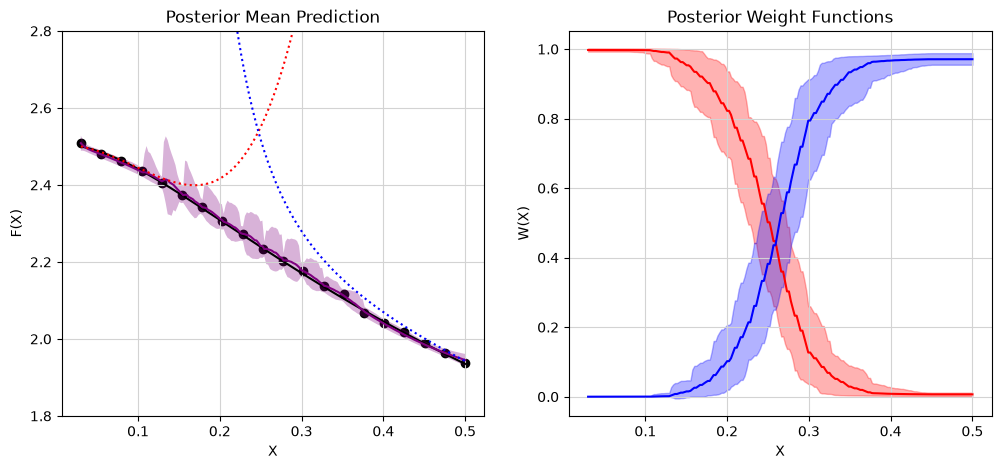

In [34]:
# Plot the predictions and weight functions
col_list = ['red','blue','green','purple','orange']

fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(x_test, fdagger, color = 'black')
ax[0].plot(x_test, pmean, color = 'purple')
for i in range(2):
    ax[0].plot(x_test, f_test[i], color = col_list[i], linestyle = 'dotted')
ax[0].scatter(x_train ,y_train,c="black")
ax[0].set_title("Posterior Mean Prediction")
ax[0].set_xlabel("X") # Update Label
ax[0].set_ylabel("F(X)") # Update Label
ax[0].set_ylim(1.8,2.8)
ax[0].fill_between(x_test.reshape(200,), plower, pupper, facecolor='purple', alpha=0.3)
ax[0].grid(True, color='lightgrey')


for i in range(2):
    ax[1].plot(x_test, wmean[:,i], color = col_list[i])
    ax[1].fill_between(x_test.reshape(200,), wlower[:,i], wupper[:,i], color = col_list[i], alpha = 0.3)
ax[1].set_title("Posterior Weight Functions")
ax[1].set_xlabel("X")
ax[1].set_ylabel("W(X)")
ax[1].grid(True, color='lightgrey')

plt.show()

## **Example 2**

The BART-BMM model is trained using the following steps.

1. Define the model set using the two lines of code shown below, each of which creates a class instance for a Taylor series expansion.

In [35]:
# Define the model set
f1 = sin_cos_exp(7,10,np.pi,np.pi) # 7th order sin(x1) + 10th order cos(x2)
f2 = sin_cos_exp(13,6,-np.pi,-np.pi) # 13th order sin(x1) + 6th order cos(x2)

# Get train data
x_train = np.loadtxt("Data/2d_x_train.txt").reshape(80,2)
x_train = x_train.reshape(2,80).transpose()

y_train = np.loadtxt("Data/2d_y_train.txt").reshape(80,1)

# Get test data
n_test = 30
x1_test = np.outer(np.linspace(-np.pi, np.pi, n_test), np.ones(n_test))
x2_test = x1_test.copy().transpose()
f0_test = (np.sin(x1_test) + np.cos(x2_test))
x_test = np.array([x1_test.reshape(x1_test.size,),x2_test.reshape(x1_test.size,)]).transpose()


2. Define the class instance of the BART-BMM model using the `Openbtmix` class. For this example, the class instance is called `mix`.

3. Set the prior information using the `set_prior()` method.

4. Fit the model using `train()`. This requires the user to pass in the data, the evaluated model set (`f_train`), and relevant MCMC arguments.

In [36]:
# Fit the BMM Model
# Evaluate the model set at the training inputs
f_train = np.concatenate([f1.evaluate(x_train)[0], f2.evaluate(x_train)[0]], axis=1)

# Initialize the Openbtmix class instance
mix = Openbtmix()

# Set prior information
mix.set_prior(k=2.0,ntree=30,nu=5,sighat=0.01,inform_prior=False)

# Train the model
fit = mix.train(x_train=x_train, y_train=y_train, f_train=f_train,
                ndpost = 5000, nadapt = 2000, nskip = 1000, adaptevery = 200, minnumbot = 4, tc = 2)


Running model...


5. Obtain the predictions from the mixed function and the corresponding weight functions using the methods `predict()` and `predict_weights()`, respectively. `predict()` requires the test inputs, the evaluated model set at those inputs, and a confidence level; `predict_weights()` requires just the test inputs and a confidence level.

In [37]:
# Evaluate the model set at the test inputs
f_test = np.concatenate([f1.evaluate(x_test)[0], f2.evaluate(x_test)[0]], axis=1)

# Get predictions
pred = mix.predict(x_test=x_test, f_test=f_test, ci=0.95)
wts = mix.predict_weights(x_test=x_test, ci=0.95)

pmean = pred["pred"]["mean"]
wmean = wts["wts"]["mean"]


Text(0.5, 0.98, 'Posterior Mean Residuals and Weight Functions')

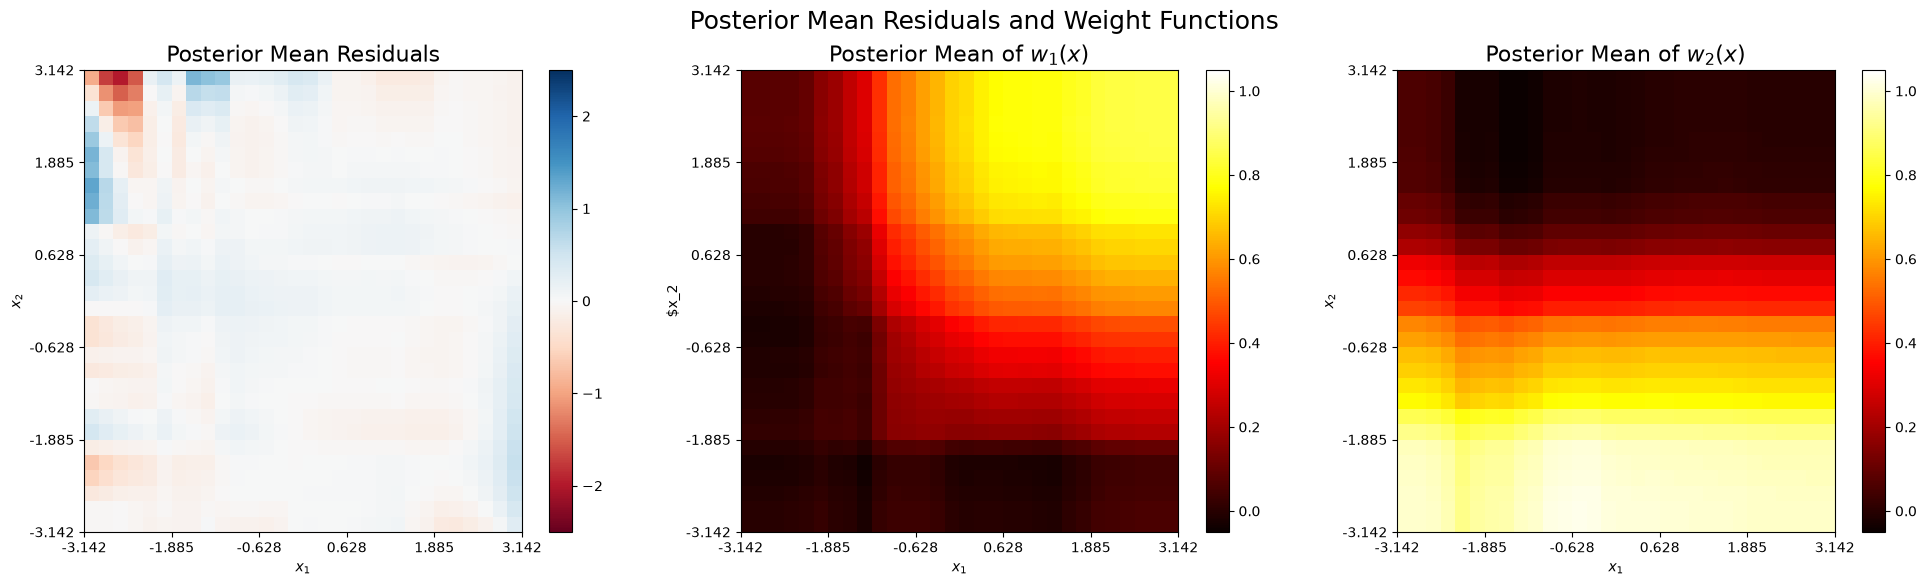

In [38]:
# The posterior mean weight functions
cmap_hot = plt.get_cmap('hot')
w1 = wmean.transpose()[0]
w2 = wmean.transpose()[1]

w1_mean = wmean.transpose()[0]
w1_mean = w1_mean.reshape(x1_test.shape).transpose()

w2_mean = wmean.transpose()[1]
w2_mean = w2_mean.reshape(x1_test.shape).transpose()

w_sum = w1_mean + w2_mean

# Posterior Mean resiudals
cmap_rb = plt.get_cmap("RdBu")
fig, ax = plt.subplots(1,3, figsize = (24,6))

pcm1 = ax[0].pcolormesh((f0_test - pmean.reshape(x1_test.shape)).transpose(),cmap = cmap_rb, vmin = -2.5, vmax = 2.5)
ax[0].set_title("Posterior Mean Residuals", size = 16)
ax[0].set(xlabel = "$x_1$", ylabel = "$x_2$")
ax[0].xaxis.set_major_locator(ticker.FixedLocator(np.round(np.linspace(0, n_test, 6),3)))
ax[0].xaxis.set_major_formatter(ticker.FixedFormatter(np.round(np.linspace(-np.pi, np.pi, 6),3)))
ax[0].yaxis.set_major_locator(ticker.FixedLocator(np.round(np.linspace(0, n_test, 6),3)))
ax[0].yaxis.set_major_formatter(ticker.FixedFormatter(np.round(np.linspace(-np.pi, np.pi, 6),3)))

fig.colorbar(pcm1,ax = ax[0])

pcm0 = ax[1].pcolormesh(w1_mean,cmap = cmap_hot, vmin = -0.05, vmax = 1.05)
ax[1].set_title("Posterior Mean of $w_1(x)$", size = 16)
ax[1].set(xlabel = "$x_1$", ylabel = "$x_2")
ax[1].xaxis.set_major_locator(ticker.FixedLocator(np.round(np.linspace(0, n_test, 6),3)))
ax[1].xaxis.set_major_formatter(ticker.FixedFormatter(np.round(np.linspace(-np.pi, np.pi, 6),3)))
ax[1].yaxis.set_major_locator(ticker.FixedLocator(np.round(np.linspace(0, n_test, 6),3)))
ax[1].yaxis.set_major_formatter(ticker.FixedFormatter(np.round(np.linspace(-np.pi, np.pi, 6),3)))
fig.colorbar(pcm0,ax = ax[1])

pcm2 = ax[2].pcolormesh(w2_mean,cmap = cmap_hot, vmin = -0.05, vmax = 1.05)
ax[2].set_title("Posterior Mean of $w_2(x)$", size = 16)
ax[2].set(xlabel = "$x_1$", ylabel = "$x_2$")
ax[2].xaxis.set_major_locator(ticker.FixedLocator(np.round(np.linspace(0, n_test, 6),3)))
ax[2].xaxis.set_major_formatter(ticker.FixedFormatter(np.round(np.linspace(-np.pi, np.pi, 6),3)))
ax[2].yaxis.set_major_locator(ticker.FixedLocator(np.round(np.linspace(0, n_test, 6),3)))
ax[2].yaxis.set_major_formatter(ticker.FixedFormatter(np.round(np.linspace(-np.pi, np.pi, 6),3)))
fig.colorbar(pcm2,ax = ax[2])
fig.suptitle("Posterior Mean Residuals and Weight Functions", size = 18)
